In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from math import log, sqrt
from pathlib import Path
from mhnlib import utils as mhn_utils
import glasbey
import re
import pandas as pd
import networkx as nx
from sklearn.decomposition import PCA
from scipy.spatial import KDTree
from tqdm.auto import tqdm
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Useful functions

In [2]:
from scipy.cluster.hierarchy import (
    linkage,
    leaves_list,
    optimal_leaf_ordering,
)
from scipy.spatial.distance import pdist, squareform
def hierarchical_haar_from_similarity(S, method="average"):
    S = np.asarray(S)
    N = S.shape[0]

    # similarity -> dissimilarity
    D = S.max() - S
    np.fill_diagonal(D, 0.0)

    d = squareform(D, checks=False)

    Z = linkage(d, method=method)
    Z = optimal_leaf_ordering(Z, d)

    clusters = {i: np.array([i], dtype=int) for i in range(N)}
    wavelets = []

    active = list(range(N))

    # scaling vectors representing the active clusters at each split
    hierarchy = [np.eye(N)]

    for k, row in enumerate(Z):
        a = int(row[0])
        b = int(row[1])

        A = clusters[a]
        B = clusters[b]

        nA = len(A)
        nB = len(B)
        n = nA + nB

        # Haar detail mode
        h = np.zeros(N)
        h[A] = np.sqrt(nB / (nA * n))
        h[B] = -np.sqrt(nA / (nB * n))

        wavelets.append(h)

        # new cluster
        new_node = N + k
        clusters[new_node] = np.concatenate([A, B])

        # update active nodes
        active.remove(a)
        active.remove(b)
        active.append(new_node)

        # scaling vectors for all current clusters
        P = np.zeros((len(active), N))

        for j, node in enumerate(active):
            inds = clusters[node]
            P[j, inds] = 1.0 / len(inds)

        hierarchy.append(P)

    scaling = np.ones(N) / np.sqrt(N)

    H = np.vstack([scaling] + wavelets[::-1])

    return H, Z, clusters, leaves_list(Z), hierarchy
def hierarchical_haar(X, method="average", metric="euclidean"):
    X = np.asarray(X)
    N = X.shape[0]

    distances = pdist(X, metric=metric)

    Z = linkage(distances, method=method)
    Z = optimal_leaf_ordering(Z, distances)

    clusters = {i: np.array([i], dtype=int) for i in range(N)}
    wavelets = []

    # active tree nodes
    active = list(range(N))

    # coarse objects at every hierarchy
    hierarchy = [X.copy()]

    for k, row in enumerate(Z):
        a = int(row[0])
        b = int(row[1])

        A = clusters[a]
        B = clusters[b]

        nA = len(A)
        nB = len(B)
        n = nA + nB

        # Haar detail
        h = np.zeros(N)
        h[A] = np.sqrt(nB / (nA * n))
        h[B] = -np.sqrt(nA / (nB * n))

        wavelets.append(h)

        # new cluster
        new_node = N + k
        clusters[new_node] = np.concatenate([A, B])

        # update active clusters
        active.remove(a)
        active.remove(b)
        active.append(new_node)

        # coarse object for every active cluster
        X_level = np.stack([
            X[clusters[node]].sum(axis=0)
            / len(clusters[node])
            for node in active
        ])

        hierarchy.append(X_level)

    scaling = np.ones(N) / np.sqrt(N)

    # coarse -> fine
    H = np.vstack([scaling] + wavelets[::-1])

    return H, Z, clusters, leaves_list(Z), hierarchy

In [3]:
def disambiguate_fixed_points(x_fp_list, weights, threshold_or_thresholds, complete_linkage):
    if isinstance(threshold_or_thresholds, float):
        thresholds = [threshold_or_thresholds] * len(x_fp_list)
    else:
        thresholds = threshold_or_thresholds
    pbar = tqdm(range(len(x_fp_list)))
    num_fps = [ ]
    x_fps = []
    w_fps = []
    for idx in pbar:
        x_unique, x_unique_counts, labels = mhn_utils.group_by_distance(x_fp_list[idx], float(thresholds[idx]), complete_linkage)
        w_unique = torch.zeros(x_unique.shape[0], weights.shape[-1])
        w_unique.index_add_(0, labels, weights[idx])
        w_unique /= x_unique_counts[:, None]
        num_fps.append(x_unique.shape[0])
        x_fps.append(torch.as_tensor(x_unique))
        w_fps.append(w_unique)
        pbar.set_postfix({"Found clusters" : num_fps[-1] })
    num_fps = torch.as_tensor(num_fps)
    return x_fps, w_fps, num_fps

In [4]:
def fisher_distance(a : torch.Tensor, b : torch.Tensor, w : torch.Tensor):
    diff = a - b
    valid = w > 0

    terms = torch.where(
        valid,
        diff.square() / torch.where(valid, w, 1.0),
        0.0,
    )

    return terms.sum(dim=-1).sqrt()

In [5]:
def get_file_df(root_path, DATASET, FILE_PATTERN):
    all_files = list(root_path.glob(f"{DATASET}{FILE_PATTERN}"))
    file_df = {'is_quenched' : [], 'num_per_label' : [], 'noise' : [], 'is_euclidean' : [], 'is_centered' : [], 'file' : []}
    for file in all_files:
        is_quenched = 'quenched' in file.stem
        num_per_label = re.search(r'per_label=(\d+)', file.stem)
        if num_per_label:
            num_per_label = int(num_per_label.group(1))
        else:
            num_per_label = np.nan
        is_euclidean = 'euclidean=True' in file.stem
        is_centered = 'centered=True' in file.stem
        logit_noise = re.search(r'noise=(\d+\.?\d*)', file.stem)
        if logit_noise:
            logit_noise = float(logit_noise.group(1))
        else:
            logit_noise = None
        file_df['is_quenched'].append(is_quenched)
        file_df['num_per_label'].append(num_per_label)
        file_df['noise'].append(logit_noise)
        file_df['is_euclidean'].append(is_euclidean)
        file_df['is_centered'].append(is_centered)
        file_df['file'].append(str(file.absolute()))
    file_df = pd.DataFrame.from_dict(file_df)
    return file_df

# Select dataset

In [67]:
DATASET = "mnist"
IS_IMAGE = DATASET in ["mnist", "stl10", "cifar10", "cifar100"]
num_per_label = 1  if IS_IMAGE else None

In [68]:
source_data_path = Path("paper_results/data/")
source_data_file = source_data_path / (f"{DATASET}_per_label={num_per_label}.pt" if IS_IMAGE else f"{DATASET}.pt")
source_data_dict = torch.load(source_data_file)
data = source_data_dict['data']
latents = source_data_dict.get('latents', None)
labels = source_data_dict['labels']
label_to_name = source_data_dict.get('label_to_name', None)
unique_labels = torch.unique(labels)
unique_labels_palette = mcolors.to_rgba_array(glasbey.create_palette(len(unique_labels)))
colors = []
for label in labels:
    label_idx = torch.where(unique_labels == label)[0].item()
    colors.append(unique_labels_palette[label_idx])
colors = np.array(colors)

# Single experiment analysis

In [69]:
experiment_name = "data_quenched"
root_path = Path(f"paper_results/experiments/{experiment_name}/")

file_df = get_file_df(root_path, DATASET, FILE_PATTERN="*weights_quenched*.pt")

plots_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/")
plots_path.mkdir(parents=True, exist_ok=True)

plots_sequences_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/sequences/")
plots_sequences_path.mkdir(parents=True, exist_ok=True)

## Load

In [70]:
is_centered = True
is_euclidean = False
is_quenched = True
logit_noise = None
file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == is_quenched)
if num_per_label is not None:
    file_mask = file_mask & (file_df['num_per_label'] == num_per_label)
    if logit_noise is not None:
        file_mask = file_mask & (file_df['noise'] == logit_noise)
    else:
        file_mask = file_mask & pd.isna(file_df['noise'])
else:
    file_mask = file_mask & pd.isna(file_df['noise'])
    if logit_noise is not None:
        file_mask = file_mask & (file_df['noise'] == logit_noise)
    else:
        file_mask = file_mask & pd.isna(file_df['noise'])
if file_mask.sum() == 0:
    raise ValueError("No files found matching the specified criteria.")
elif file_mask.sum() > 1:
    raise ValueError("Multiple files found matching the specified criteria.")
file_name = file_df[file_mask]['file'].iloc[0]

save_file_structure = f"{DATASET}"
if num_per_label is not None:
    save_file_structure += f"_per_label={num_per_label}"
save_file_structure += f"_quenched={is_quenched}_centered={is_centered}_euclidean={is_euclidean}"

In [71]:
data_dict = torch.load(file_name)
all_weights = data_dict['weights']
shift = data_dict['shift']
rms = data_dict['rms']
betas = data_dict['betas']
biases = data_dict['biases']
patterns = data_dict['patterns']
K = patterns.shape[0]
gram = patterns @ patterns.T
patterns_cov = torch.cov(patterns.T)
all_x = all_weights @ patterns
beta_c = 1.0/torch.linalg.eigvalsh(mhn_utils.get_dual_symmetric_stability_matrix(gram, torch.ones(K)/K))[-1].item()
beta_sigma = 1.0/torch.var(patterns, dim=0).sum().item()
#beta_max = 1.0/torch.norm(patterns, dim=1).max().item()
beta_nn = 1.0/KDTree(patterns.cpu().numpy()).query(patterns.cpu().numpy(), k=2)[0][:,1].mean()**2

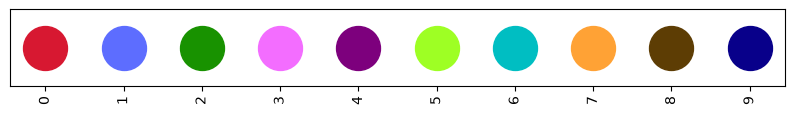

In [72]:
fig, ax = plt.subplots(figsize=(len(unique_labels), 1))
for label_idx, label in enumerate(unique_labels):
    ax.scatter(label_idx, 0, color=unique_labels_palette[label_idx], s=1000)
ax.set_xticks(range(len(unique_labels)))
if label_to_name is not None and label_to_name != {}:
    ax.set_xticklabels([label_to_name[label.item()] for label in unique_labels], rotation=90)
else:
    ax.set_xticklabels([str(label.item()) for label in unique_labels], rotation=90)
ax.yaxis.set_visible(False)
if IS_IMAGE:
    plt.savefig(plots_path /  (f"{DATASET}_per_label={num_per_label}_labels_palette.pdf"), bbox_inches='tight', dpi=300)
else:
    plt.savefig(plots_path /  (f"{DATASET}_labels_palette.pdf"), bbox_inches='tight', dpi=300)
plt.show()

## Derived quantities

In [73]:
mean_entropy =mhn_utils.get_entropy(all_weights).mean(dim=-1)
scaled_mean_entropy = mean_entropy / log(K)
uniform_idx = torch.argwhere(
    1-scaled_mean_entropy < 1e-4
).flatten()
if len(uniform_idx) == 0:
    start_idx = 0
start_idx = uniform_idx[-1].item()
x_fps, w_fps, num_fps = (
    disambiguate_fixed_points(
        all_x[start_idx:],
        all_weights[start_idx:],
        betas[start_idx:].rsqrt(),
        complete_linkage=False,
    )
)
x_fps = (
    list(all_x[:start_idx].mean(dim=1, keepdim=True))
    + x_fps
)
w_fps = (
    list(all_weights[:start_idx].mean(dim=1, keepdim=True))
    + w_fps
)
num_fps = torch.cat([
    torch.ones(start_idx, dtype=torch.long),
    num_fps,
])
jump_indices = (
    torch.argwhere(
        torch.diff(num_fps) > 0
    ).flatten()
    + 1
)
jump_indices = torch.cat([
    torch.zeros(1, dtype=jump_indices.dtype),
    jump_indices,
    
])

  0%|          | 0/603 [00:00<?, ?it/s]

In [74]:
edgelist_from = []
edgelist_to = []
edge_weights = []
# --------------------------------------------------
# Match every FP to its closest FP at previous beta
# --------------------------------------------------
for beta_idx in range(1, len(betas)):
    w_fp = w_fps[beta_idx]
    w_fp_prev = w_fps[beta_idx - 1]
    dist = fisher_distance(
        w_fp[:, None, :],
        w_fp_prev[None, :, :],
        w_fp_prev[None, :, :],
    )
    closest_prev_idx = dist.argmin(dim=1)
    for idx in range(len(w_fp)):
        parent_idx = closest_prev_idx[idx].item()
        # old -> new
        edgelist_from.append(
            (beta_idx - 1, parent_idx)
        )
        edgelist_to.append(
            (beta_idx, idx)
        )
        edge_weights.append(
            dist[idx, parent_idx].item()
        )
# --------------------------------------------------
# Nodes
# --------------------------------------------------
fp_nodes = []
for beta_idx in range(len(w_fps)):
    for idx in range(len(w_fps[beta_idx])):
        fp_nodes.append((beta_idx, idx))
# --------------------------------------------------
# DAG
# --------------------------------------------------
G = nx.DiGraph()
G.add_nodes_from(fp_nodes)
G.add_weighted_edges_from(
    zip(
        edgelist_from,
        edgelist_to,
        edge_weights,
    )
)
branching_nodes = [
node for node in G.nodes
if G.out_degree(node) > 1
]
branching_indices = torch.as_tensor([0] + [
    node[0] for node in branching_nodes
] + [len(betas) - 1])


In [ ]:
if IS_IMAGE:
    from diffusers import AutoencoderKL
    ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
    ae_model = ae_model.to(device).eval()
    ae_model.requires_grad_(False)
    ae_scaling = ae_model.config.scaling_factor

    C_latents, H_latents, W_latents = latents.shape[1:]

    image_fps = []
    for x in x_fps:
        torch.cuda.empty_cache()
        images = ae_model.decode((x*rms + shift).view(-1,C_latents, H_latents, W_latents).to(device)).sample.cpu()
        image_fps.append(images)

    #image_annealed_fps = []
    #for x in x_annealed_fps:
    #    torch.cuda.empty_cache()
    #    images = ae_model.decode(x.view(-1,C_latents, H_latents, W_latents).to(device)).sample.cpu()
    #    image_annealed_fps.append(images)
else:
    image_fps = None
    #image_annealed_fps = None

## Plots

### Subspace similarities

In [ ]:
H, Z, clusters, order, hierarchy = hierarchical_haar(patterns)
H = torch.as_tensor(H, dtype=torch.float32)

In [ ]:
def orth_basis(X, rtol=1e-10):
    """
    X: (p, d), vectors stored as rows.
    Returns Q: (d, rank), orthonormal basis of their span.
    """
    U, s, _ = np.linalg.svd(X.T, full_matrices=False)

    if len(s) == 0:
        return U[:, :0]

    rank = np.sum(s > rtol * s[0])

    return U[:, :rank]


def get_similarities(x_coll_1, x_coll_2):
    similarities = np.zeros((len(x_coll_1), len(x_coll_2)))

    for counter_1, x_1 in enumerate(x_coll_1):
        Q_1 = orth_basis(np.asarray(x_1))

        for counter_2, x_2 in enumerate(x_coll_2):
            Q_2 = orth_basis(np.asarray(x_2))

            overlap = np.linalg.norm(Q_1.T @ Q_2, "fro")**2

            similarity = overlap / np.sqrt(
                Q_1.shape[1] * Q_2.shape[1]
            )

            similarities[counter_1, counter_2] = similarity

    return similarities

In [ ]:
x_fps_jump = [x_fps[idx] for idx in jump_indices]
sim_hn_hier = get_similarities(x_fps_jump, hierarchy[::-1])
pca_model = PCA(n_components=min(patterns.shape[0], patterns.shape[1])).fit(patterns.cpu().numpy())
pca_bases = [ pca_model.components_[:idx]  for idx in range(1, len(hierarchy)+1)]

sim_hn_pca = get_similarities(x_fps_jump, pca_bases)
from sklearn.cluster import KMeans
kmeans_bases = [ KMeans(n_clusters=idx, random_state=1101252).fit(patterns.cpu().numpy()).cluster_centers_ for idx in range(1, len(hierarchy)+1)]

sim_hn_kmeans = get_similarities(x_fps_jump, kmeans_bases)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im0 = axs[0].imshow(sim_hn_hier, aspect='equal', cmap='coolwarm', vmin=0, vmax=1)
axs[0].set_title("Hierarchical Haar")
plt.colorbar(im0, ax=axs[0], shrink=0.8)
im1 = axs[1].imshow(sim_hn_pca, aspect='equal', cmap='coolwarm', vmin=0, vmax=1)
axs[1].set_title("PCA")
plt.colorbar(im1, ax=axs[1], shrink=0.8)
im2 = axs[2].imshow(sim_hn_kmeans, aspect='equal', cmap='coolwarm', vmin=0, vmax=1)
axs[2].set_title("KMeans")
plt.colorbar(im2, ax=axs[2], shrink=0.8)
plt.savefig(plots_path /  (save_file_structure + f"_recon_basis.pdf"), bbox_inches='tight', dpi=300)
plt.close()

In [ ]:
#num_cols = 10
#num_rows = int(np.ceil(len(hierarchy)/num_cols))
#fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
#if num_rows == 1:
#    axs = axs[None,...]
#for reverse_hierarchy_level in range(len(hierarchy)):
#    hierarchy_level = len(hierarchy) - 1 - reverse_hierarchy_level
#    row_idx = hierarchy_level // num_cols
#    col_idx = hierarchy_level % num_cols
#    x_hl = torch.as_tensor(hierarchy[hierarchy_level], dtype=torch.float32)
#    x_hl_propagated = mhn_utils.deterministic_dynamics(patterns.to('cuda'), biases.to('cuda'), betas.to('cuda'), x_hl.to('cuda'), num_iterations=1000).cpu().squeeze(1)
#    distances = torch.norm(x_hl_propagated - x_hl[None,...], dim=-1)
#    axs[row_idx, col_idx].imshow(distances.clamp(min=1e-5).log10(), aspect='auto', cmap='seismic', vmin=-5, vmax=0)
#    axs[row_idx, col_idx].set_xticks(np.arange(0, distances.shape[1], 1))
#plt.show()

In [ ]:
num_cols = 10
num_rows = int(np.ceil(len(hierarchy)/num_cols))
fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for hierarchy_level in range(len(hierarchy)-1, -1, -1):
    plot_idx = len(hierarchy) - 1 - hierarchy_level
    row_idx = plot_idx // num_cols
    col_idx = plot_idx % num_cols
    x_hl = torch.as_tensor(hierarchy[hierarchy_level], dtype=torch.float32)
    A =  patterns @ torch.linalg.pinv(x_hl)
    patterns_fitted = A @ x_hl
    axs[row_idx, col_idx].imshow(patterns_fitted @ patterns_fitted.T, aspect='equal', cmap='coolwarm', vmin=gram.min().item(), vmax=gram.max().item())
    axs[row_idx, col_idx].set_title(f"Nc: {x_hl.shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_hierarchical_haar_effective_gram.pdf"), bbox_inches='tight', dpi=300)
plt.close()


fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for hierarchy_level in range(len(hierarchy)-1, -1, -1):
    plot_idx = len(hierarchy) - 1 - hierarchy_level
    row_idx = plot_idx // num_cols
    col_idx = plot_idx % num_cols
    x_hl = torch.as_tensor(hierarchy[hierarchy_level], dtype=torch.float32)
    axs[row_idx, col_idx].imshow(torch.cov(x_hl.T), aspect='equal', cmap='coolwarm', vmin=patterns_cov.min().item(), vmax=patterns_cov.max().item())
    axs[row_idx, col_idx].set_title(f"Nc: {x_hl.shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_hierarchical_haar_covariance.pdf"), bbox_inches='tight', dpi=300)
plt.close()

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(gram, aspect='equal', cmap='coolwarm', vmin=gram.min().item(), vmax=gram.max().item())
ax.yaxis.set_visible(False)
ax.xaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_gram.pdf"), bbox_inches='tight', dpi=300)
plt.close()
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(patterns_cov, aspect='equal', cmap='coolwarm', vmin=patterns_cov.min().item(), vmax=patterns_cov.max().item())
ax.yaxis.set_visible(False)
ax.xaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_covariance.pdf"), bbox_inches='tight', dpi=300)
plt.close()
num_cols = 10
num_rows = int(np.ceil(len(jump_indices)/num_cols))
fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for idx, beta_idx in enumerate(jump_indices):
    row_idx = idx // num_cols
    col_idx = idx % num_cols
    A =  patterns @ torch.linalg.pinv(x_fps[beta_idx])
    patterns_fitted = A @ x_fps[beta_idx]
    axs[row_idx, col_idx].imshow(patterns_fitted @ patterns_fitted.T, aspect='equal', cmap='coolwarm', vmin=gram.min().item(), vmax=gram.max().item())
    axs[row_idx, col_idx].set_title(f"Nfp: {x_fps[beta_idx].shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_fixed_points_effective_gram.pdf"), bbox_inches='tight', dpi=300)
plt.close()


fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for idx, beta_idx in enumerate(jump_indices):
    row_idx = idx // num_cols
    col_idx = idx % num_cols
    axs[row_idx, col_idx].imshow(torch.cov(x_fps[beta_idx].T), aspect='equal', cmap='coolwarm', vmin=patterns_cov.min().item(), vmax=patterns_cov.max().item())
    axs[row_idx, col_idx].set_title(f"Nfp: {x_fps[beta_idx].shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_fixed_points_effective_covariance.pdf"), bbox_inches='tight', dpi=300)
plt.close()

### Entropy

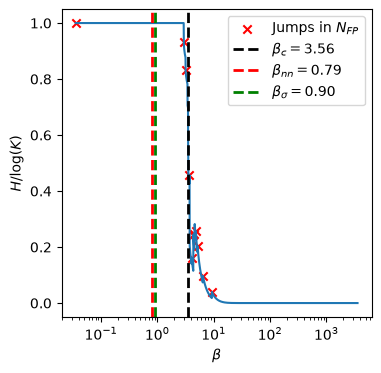

In [75]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(betas, mean_entropy/log(K))
ax.scatter(
    betas[jump_indices],
    mean_entropy[jump_indices]/log(K),
    color='r',
    marker='x',
    label="Jumps in $N_{FP}$",
)
#ax.scatter(
#    betas[branching_indices],
#    mean_entropy[branching_indices]/log(K),
#    color='b',
#    marker='x',
#    label="Branching points",
#)
ax.axvline(beta_c, color='k', linestyle='--', label=f"$\\beta_c={beta_c:.2f}$", linewidth=2.0)
ax.axvline(beta_nn, color='red', linestyle='--', label="$\\beta_{nn}=$" + f"{beta_nn:.2f}", linewidth=2.0)
#ax.axvline(beta_max, color='blue', linestyle='--', label="$\\beta_{max}=$" + f"{beta_max:.2f}", linewidth=2.0)
ax.axvline(beta_sigma, color='green', linestyle='--', label="$\\beta_\\sigma=$" + f"{beta_sigma:.2f}", linewidth=2.0)
plt.xscale('log')
ax.set_xlabel("$\\beta$")
ax.set_ylabel("$H/\\log(K)$")
plt.legend()
plt.savefig(plots_path / f"{save_file_structure}_entropy.pdf", dpi=300, bbox_inches='tight')
plt.show()

### PCA plots

In [ ]:
pca_model = PCA(n_components=5).fit(patterns)
patterns_proj = pca_model.transform(patterns)
grayscale_conversion = torch.tensor([0.299, 0.587, 0.114])
for beta_idx in jump_indices:
    x_fp = x_fps[beta_idx]
    x_fp_proj = torch.as_tensor(pca_model.transform(x_fp))
    closest_fp_idx = ((patterns[:,None,:] - x_fp[None,:,:])**2).sum(dim=-1).argmin(dim=1)
    fig, axs = plt.subplots(ncols=2, figsize=(8,3))
    axs[0].scatter(patterns_proj[:,0], patterns_proj[:,1], s= 70, color=colors)
    axs[0].scatter(x_fp_proj[:,0], x_fp_proj[:,1], color='gray',  marker='s', s=50, edgecolors='black')
    for idx in range(len(x_fp)):
        axs[0].text(x_fp_proj[idx,0], x_fp_proj[idx,1], f"({beta_idx},{idx})", fontsize=8, color='black', ha='center', va='top')
    axs[0].set_xlabel("PCA #1")
    axs[0].set_ylabel("PCA #2")
    axs[1].scatter(patterns_proj[:,2], patterns_proj[:,3], s = 70, color=colors)
    axs[1].scatter(x_fp_proj[:,2], x_fp_proj[:,3], color='gray',  marker='s', s=50, edgecolors='black')
    for idx in range(len(x_fp)):
        axs[1].text(x_fp_proj[idx,2], x_fp_proj[idx,3], f"({beta_idx},{idx})", fontsize=8, color='black', ha='center', va='top')
    axs[1].set_xlabel("PCA #3")
    axs[1].set_ylabel("PCA #4")
    axs[0].set_aspect('equal')
    axs[1].set_aspect('equal')
    plt.savefig(plots_sequences_path /  (save_file_structure + f"_beta_idx={beta_idx}_pca_fp.pdf"), bbox_inches='tight', dpi=300)
    plt.close()
    if IS_IMAGE:
        fig, axs = plt.subplots(ncols=image_fps[beta_idx].shape[0], figsize=(4*image_fps[beta_idx].shape[0],4))
        if image_fps[beta_idx].shape[0] == 1:
            axs = [axs]
        for idx in range(image_fps[beta_idx].shape[0]):
            image = (1+image_fps[beta_idx][idx].permute(1,2,0).clip(-1,1))/2
            
            if DATASET == "mnist":
                axs[idx].imshow(image @ grayscale_conversion, vmin=0, vmax=1, cmap='gray')
            else:
                axs[idx].imshow(image)
            axs[idx].set_title(f"({beta_idx},{idx})")    
        plt.savefig(plots_sequences_path /  (save_file_structure + f"_beta_idx={beta_idx}_image_fp.pdf"), bbox_inches='tight', dpi=300)
        plt.close()

# Cont. Annealing

In [ ]:
def run_annealing(patterns,biases, 
                  noise_ic_factor,
                  beta_ic_factor, 
                  beta_final_factor, beta_logspace, num_ics_per_pattern, num_iterations_per_beta, num_betas, batch_size, device):
    K = patterns.shape[0]
    
    
    stab_matr = mhn_utils.get_dual_symmetric_stability_matrix(gram, torch.ones(K)/K)
    beta_c = 1.0/torch.linalg.eigvalsh(stab_matr).max().item()
    beta_ic = beta_ic_factor * beta_c
    beta_final = beta_final_factor * beta_c
    noise_ic_std = noise_ic_factor / sqrt(beta_c)
    x_init = patterns.expand(num_ics_per_pattern, K, -1) + torch.randn(num_ics_per_pattern, K, patterns.shape[-1])*noise_ic_std
    x_init = x_init.view(-1, patterns.shape[-1])
    w_noisy_ic = torch.softmax( (x_init @ patterns.T + biases)*beta_ic, dim=-1)
    torch.manual_seed(1101252)
    w_annealed = []
    for batch_start in tqdm(range(0, num_ics_per_pattern*K, batch_size)):
        torch.cuda.empty_cache()
        batch_end = min(batch_start + batch_size, num_ics_per_pattern*K)
        w_annealed_batch, betas = mhn_utils.dual_deterministic_dynamics_cont_annealing(gram.to(device),
                                                                              biases.to(device),
                                                                              w_noisy_ic[batch_start:batch_end].to(device),
                                                                              beta_ic,
                                                                              beta_final,
                                                                              beta_logspace=beta_logspace,
                                                                              num_betas=num_betas,
                                                                              num_iterations_per_beta=num_iterations_per_beta,
                                                                                verbose=False,
                                                                                dt = None)
        w_annealed_batch = w_annealed_batch.cpu().squeeze()
        w_annealed.append(w_annealed_batch)
    w_annealed = torch.cat(w_annealed, dim=1)
    betas = betas.cpu().squeeze()
    return w_annealed, beta_ic, beta_final, betas

In [ ]:
is_centered = False
is_euclidean = True
raw_patterns = torch.clone(data.view(data.shape[0],-1)) if latents is None else torch.clone(latents.view(latents.shape[0],-1))
if is_centered or is_euclidean:
    shift, rms, patterns = mhn_utils.shift_and_rms(raw_patterns)
else:
    shift = torch.zeros(raw_patterns.shape[-1])
    rms = raw_patterns.norm(dim=1).square().mean().sqrt()
    rms = rms.clamp_min(1e-12)
    patterns = raw_patterns / rms
K = patterns.shape[0]
gram = patterns @ patterns.T
if is_euclidean:
    biases = -0.5*torch.diagonal(gram)
else:
    biases = torch.zeros(K)

In [ ]:
w_annealed, beta_ic, beta_final, betas = run_annealing(patterns,
                            biases, 
                            noise_ic_factor=1.0,
                            beta_ic_factor=1.0, 
                            beta_final_factor=10.0, 
                            beta_logspace = False,
                            num_ics_per_pattern=100, num_iterations_per_beta=100, num_betas=2000, batch_size=1000, device=device)

In [ ]:
x_annealed =  torch.einsum("...k,ki->...i", w_annealed, patterns)

In [ ]:
x_annealed_beta_distances = torch.diff(x_annealed, dim=0).norm(dim=-1)

In [ ]:
pca_model = PCA(n_components=5).fit(patterns)
patterns_proj = pca_model.transform(patterns)
x_annealed_proj = torch.as_tensor(pca_model.transform(x_annealed.view(-1, patterns.shape[-1]))).view(x_annealed.shape[0], x_annealed.shape[1], -1)

In [ ]:
plt.scatter(patterns_proj[:,0], patterns_proj[:,1], s= 70, color=colors)
for ic_idx in range(x_annealed_proj.shape[1]):
    plt.plot(x_annealed_proj[:,ic_idx,0], x_annealed_proj[:,ic_idx,1], color='gray', alpha=0.5)

# Multi-experiments analysis

In [ ]:
is_centered = False
is_euclidean = True
is_quenched = True
num_per_label = 1 if IS_IMAGE else None
if num_per_label is not None:
    file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == is_quenched) & (file_df['num_per_label'] == num_per_label)
else:
    file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == is_quenched)
if file_mask.sum() == 0:
    raise ValueError("No files found matching the specified criteria.")
sub_file_df = file_df[file_mask]
sub_file_df = sub_file_df.sort_values(by=['noise'])

save_file_structure = f"{DATASET}"
if num_per_label is not None:
    save_file_structure += f"_per_label={num_per_label}"
save_file_structure += f"_quenched={is_quenched}_centered={is_centered}_euclidean={is_euclidean}"

In [ ]:
database = {}
for _,file in sub_file_df.iterrows():
    data_dict = torch.load(file['file'])
    all_weights = data_dict['weights']
    shift = data_dict['shift']
    rms = data_dict['rms']
    betas = data_dict['betas']
    biases = data_dict['biases']
    patterns = data_dict['patterns']
    gram = patterns @ patterns.T
    all_x = all_weights @ patterns
    mean_entropy = mhn_utils.get_entropy(all_weights).mean(dim=-1)
    database[file.noise] = {"patterns" : patterns,
                             "all_weights" : all_weights,
                               "all_x" : all_x,
                                 "mean_entropy" : mean_entropy,
                                  "betas" : betas, "shift" : shift, "rms" : rms, "biases" : biases}

In [ ]:
source_data_path = Path("paper_results/data/")
source_data_file = source_data_path / (f"{DATASET}_per_label={num_per_label}.pt" if IS_IMAGE else f"{DATASET}.pt")
source_data_dict = torch.load(source_data_file)
source_data = source_data_dict['data']
source_latents = source_data_dict.get('latents', None)
labels = source_data_dict['labels']
label_to_name = source_data_dict.get('label_to_name', None)

### Derived quantities

In [ ]:
for noise in database.keys():
    patterns = database[noise]["patterns"]
    K = patterns.shape[0]
    gram = patterns @ patterns.T
    ssm = mhn_utils.get_dual_symmetric_stability_matrix(gram, torch.ones(K)/K, return_proj=False)
    beta_c = 1.0/torch.linalg.eigvalsh(ssm)[-1]
    database[noise]["beta_c"] = beta_c.item()

In [ ]:
for noise in database.keys():
    betas = database[noise]["betas"]
    K = database[noise]["patterns"].shape[0]
    mean_entropy = database[noise]["mean_entropy"]
    scaled_mean_entropy = mean_entropy / log(K)
    all_x = database[noise]["all_x"]
    all_weights = database[noise]["all_weights"]

    uniform_idx = torch.argwhere(
        1-scaled_mean_entropy < 1e-4
    ).flatten()

    if len(uniform_idx) == 0:
        start_idx = 0

    start_idx = uniform_idx[-1].item()

    print(f"Noise: {noise:.2f}. Start index for disambiguation: {start_idx}. Scaled entropy: {scaled_mean_entropy[start_idx]:.4f}. Mean entropy: {mean_entropy[start_idx]:.4f}. Beta: {betas[start_idx]:.4f}")

    x_fps, w_fps, num_fps = (
        disambiguate_fixed_points(
            all_x[start_idx:],
            all_weights[start_idx:],
            database[noise]["betas"][start_idx:].rsqrt(),
            complete_linkage=False,
        )
    )

    x_fps = (
        list(all_x[:start_idx].mean(dim=1, keepdim=True))
        + x_fps
    )


    w_fps = (
        list(all_weights[:start_idx].mean(dim=1, keepdim=True))
        + w_fps
    )

    num_fps = torch.cat([
        torch.ones(start_idx, dtype=torch.long),
        num_fps,
    ])

    jump_indices = (
        torch.argwhere(
            torch.diff(num_fps) > 0
        ).flatten()
        + 1
    )

    jump_indices = torch.cat([
        torch.zeros(1, dtype=jump_indices.dtype),
        jump_indices,
    ])

    database[noise]["x_fps"] = x_fps
    database[noise]["w_fps"] = w_fps
    database[noise]["num_fps"] = num_fps
    database[noise]["jump_indices"] = jump_indices

    print(torch.argwhere(torch.diff(num_fps) < 0).flatten())

In [ ]:
for noise in database.keys():

    w_fps = database[noise]["w_fps"]
    betas = database[noise]["betas"]

    edgelist_from = []
    edgelist_to = []
    edge_weights = []

    # --------------------------------------------------
    # Match every FP to its closest FP at previous beta
    # --------------------------------------------------

    for beta_idx in range(1, len(betas)):

        w_fp = w_fps[beta_idx]
        w_fp_prev = w_fps[beta_idx - 1]

        dist = fisher_distance(
            w_fp[:, None, :],
            w_fp_prev[None, :, :],
            w_fp_prev[None, :, :],
        )

        closest_prev_idx = dist.argmin(dim=1)

        for idx in range(len(w_fp)):

            parent_idx = closest_prev_idx[idx].item()

            # old -> new
            edgelist_from.append(
                (beta_idx - 1, parent_idx)
            )

            edgelist_to.append(
                (beta_idx, idx)
            )

            edge_weights.append(
                dist[idx, parent_idx].item()
            )

    # --------------------------------------------------
    # Nodes
    # --------------------------------------------------

    fp_nodes = []

    for beta_idx in range(len(w_fps)):
        for idx in range(len(w_fps[beta_idx])):
            fp_nodes.append((beta_idx, idx))

    # --------------------------------------------------
    # DAG
    # --------------------------------------------------

    G = nx.DiGraph()

    G.add_nodes_from(fp_nodes)

    G.add_weighted_edges_from(
        zip(
            edgelist_from,
            edgelist_to,
            edge_weights,
        )
    )

    branching_nodes = [
    node for node in G.nodes
    if G.out_degree(node) > 1
    ]

    database[noise]["dag"] = G
    database[noise]["branching_nodes"] = branching_nodes

## Plots

In [ ]:
noise_colors = { noise : cm.coolwarm(noise / max(database.keys())) for noise in database.keys() }

### Entropy

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
beta_c = None
for noise in database.keys():
    beta_c = database[noise]["beta_c"]
    K = database[noise]["patterns"].shape[0]
    mean_entropy = database[noise]["mean_entropy"]
    betas = database[noise]["betas"]
    ax.plot(betas, mean_entropy/log(K), color=noise_colors[noise], label=f"$\\sigma={noise:.2f}$")
if beta_c is not None:
    ax.axvline(beta_c, color='k', linestyle='--', label=f"$\\beta_c={beta_c:.2f}$", linewidth=2.0)
plt.xscale('log')
ax.set_xlabel("$\\beta$")
ax.set_ylabel("$H/\\log(K)$")
plt.legend()
plt.savefig(plots_path / f"{save_file_structure}_multi_entropy.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Branching plots

In [ ]:
fig, axs = plt.subplots(ncols=len(database.keys()), figsize=(4*len(database.keys()), 4), sharex=True, sharey=True)
for plot_idx, noise in enumerate(database.keys()):
    dag = database[noise]["dag"]
    branching_nodes = database[noise]["branching_nodes"]
    x_fps = database[noise]["x_fps"]
    betas = database[noise]["betas"]
    patterns = database[noise]["patterns"]
    pca_model = PCA(n_components=2).fit(patterns)
    patterns_2d = pca_model.transform(patterns)
    axs[plot_idx].scatter(patterns_2d[:, 0], patterns_2d[:, 1], color='black', label=f"$\\sigma={noise:.2f}$", alpha=0.5, s=100)
    axs[plot_idx].set_title(f"$\\sigma={noise:.2f}$")
    axs[plot_idx].set_xlabel("PCA 1")
    axs[plot_idx].set_ylabel("PCA 2")
    beta_branching = [betas[node[0]].item() for node in branching_nodes]
    if len(beta_branching) <= 1:
        continue
    beta_min = min(beta_branching[:-1]) if len(beta_branching) > 1 else 0.0
    beta_max = max(beta_branching[:-1]) if len(beta_branching) > 1 else 0.0
    beta_c = database[noise]["beta_c"]
    for node_from in branching_nodes:
        color = cm.viridis((betas[node_from[0]].item() - beta_min) / (beta_max - beta_min)) if beta_max > beta_min else 'k'
        x_from  = x_fps[node_from[0]][node_from[1]]
        x_from_2d = pca_model.transform(x_from[None, :])[0]
        nodes_to = list(nx.neighbors(dag, node_from))
        axs[plot_idx].scatter(x_from_2d[0], x_from_2d[1], color=color, s=50, edgecolor='black')
        for node_to in nodes_to:
            x_to = x_fps[node_to[0]][node_to[1]]
            x_to_2d = pca_model.transform(x_to[None, :])[0]
            axs[plot_idx].quiver(
                x_from_2d[0], x_from_2d[1],
                x_to_2d[0]-x_from_2d[0], x_to_2d[1]-x_from_2d[1],
                angles='xy', scale_units='xy', scale=1, color=color, linewidth=3
            )
    colorbar = plt.cm.ScalarMappable(cmap=cm.viridis, norm=mcolors.Normalize(vmin=beta_min/beta_c, vmax=beta_max/beta_c))
    axins = axs[plot_idx].inset_axes([-0.05, -0.3, 1.0, 0.04])
    cbar = plt.colorbar(colorbar, cax=axins, orientation='horizontal', label="$\\beta/\\beta_c$")
plt.savefig(plots_path / f"{save_file_structure}_multi_branching_dag.pdf", dpi=300, bbox_inches='tight')
plt.show()